In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
import pickle
import nltk
from nltk.tokenize import word_tokenize
from collections import defaultdict
from gensim.models import Word2Vec
import nltk
nltk.download('punkt')
from google.colab import drive
drive.mount('/content/gdrive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [15]:

class Tokenizer:
    def __init__(self, max_length=512):
        self.max_length = max_length
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}

    def build_vocab(self, texts):
        for text in texts:
            tokens = word_tokenize(text)
            for token in tokens:
                if token not in self.word2idx:
                    self.word2idx[token] = len(self.word2idx)

    def tokenize(self, text):
        tokens = word_tokenize(text)
        input_ids = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
        input_ids = input_ids[:self.max_length] + [self.word2idx['<PAD>']] * (self.max_length - len(input_ids))
        attention_mask = [1 if i < len(tokens) else 0 for i in range(self.max_length)]
        return torch.tensor(input_ids), torch.tensor(attention_mask)
    def get_vocab(self):
        return dict(self.word2idx)

    @property
    def pad_token_id(self):
        return self.word2idx['<PAD>']

In [16]:

class FakeNewsClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx,
                 embeddings=None):
        super(FakeNewsClassifier, self).__init__()

        if embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(embeddings, padding_idx=pad_idx, freeze=False)
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        self.conv = nn.Conv1d(in_channels=embedding_dim, out_channels=128, kernel_size=5)
        self.lstm = nn.LSTM(128, hidden_dim, num_layers=n_layers, bidirectional=bidirectional, dropout=dropout,
                            batch_first=True)
        self.fc1 = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.embedding(text)
        embedded = embedded.permute(0, 2, 1)
        conv_out = F.relu(self.conv(embedded))
        conv_out = self.batch_norm1(conv_out)
        conv_out = conv_out.permute(0, 2, 1)
        lstm_out, (hidden, cell) = self.lstm(conv_out)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        else:
            hidden = hidden[-1, :, :]
        dense_out = F.relu(self.fc1(hidden))
        dense_out = self.batch_norm2(dense_out)
        dense_out = self.dropout(dense_out)
        output = self.fc2(dense_out)
        return output

In [17]:

class NewsDataset(Dataset):
    def __init__(self, fake_file, true_file, tokenizer, max_length,cache_file='tokenized_data.pkl'):
        self.fake_data = pd.read_csv(fake_file)
        self.true_data = pd.read_csv(true_file)
        # self.fake_data = pd.read_csv(fake_file, nrows=int(pd.read_csv(fake_file).shape[0]/1000 ))
        # self.true_data = pd.read_csv(true_file, nrows=int(pd.read_csv(true_file).shape[0]/1000 ))

        # Add a label column: 1 for fake news, 0 for true news
        self.fake_data['label'] = 1
        self.true_data['label'] = 0

        # Combine the datasets
        self.data = pd.concat([self.fake_data, self.true_data], ignore_index=True)

        self.tokenizer = tokenizer
        self.max_length = max_length
        print("Tokenizing data...")
        self.tokenized_data = []
        texts = self.data['title'] + " " + self.data['text']
        self.tokenizer.build_vocab(texts)
        for text in texts:
            input_ids, attention_mask = self.tokenizer.tokenize(text)
            self.tokenized_data.append((input_ids, attention_mask))
        # self.tokenized_data = []
        # texts = self.data['title'] + " " + self.data['text']
        # self.tokenizer.build_vocab(texts)
        # for text in texts:
        #     input_ids, attention_mask = self.tokenizer.tokenize(text)
        #     self.tokenized_data.append((input_ids, attention_mask))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        idx = idx.item()
        input_ids, attention_mask = self.tokenized_data[idx]
        label = self.data.iloc[idx]['label']
        return {
            'input_ids': input_ids.to(device),
            'attention_mask': attention_mask.to(device),
            'label': torch.tensor(label, dtype=torch.long).to(device)
        }

In [18]:

def create_data_loader(fake_file, true_file, tokenizer, max_length, batch_size):
    dataset = NewsDataset(fake_file, true_file, tokenizer, max_length)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)


def load_embeddings(embedding_file, vocab):
    embeddings = {}
    with open(embedding_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = torch.tensor([float(val) for val in values[1:]], dtype=torch.float)
            embeddings[word] = vector
    embedding_matrix = torch.zeros((len(vocab), len(vector)))
    for word, idx in vocab.items():
        if word in embeddings:
            embedding_matrix[idx] = embeddings[word]
        else:
            embedding_matrix[idx] = torch.randn(len(vector))
    return embedding_matrix

# def load_embeddings(embedding_file, vocab):
#     # Load the pre-trained embeddings from the .pth file
#     embeddings_tensor = torch.load(embedding_file)
#
#     # Create a dictionary to map words to their embeddings
#     embeddings = {word: embeddings_tensor[idx] for idx, word in enumerate(vocab)}
#
#     # Initialize the embedding matrix with random values
#     embedding_matrix = torch.randn((len(vocab), embeddings_tensor.size(1)))
#
#     # Populate the embedding matrix with the pre-trained embeddings
#     for word, idx in vocab.items():
#         if word in embeddings:
#             embedding_matrix[idx] = embeddings[word]
#         else:
#             embedding_matrix[idx] = torch.randn(embeddings_tensor.size(1))
#
#     return embedding_matrix

def compute_accuracy(outputs, labels):
    # Apply a sigmoid to the outputs to get probabilities
    probs = torch.sigmoid(outputs)
    # Convert probabilities to binary predictions (0 or 1)
    preds = (probs > 0.5).float()
    # Compare predictions with the actual labels
    correct = (preds == labels).float()
    # Calculate accuracy
    accuracy = correct.sum() / len(correct)
    return accuracy.item()

cuda
Tokenizing data...
starting
Embedding: /content/gdrive/My Drive/glove.6B.100d.txt, LR: 0.001, Dropout: 0, Hidden Dim: 128, Layers: 1, Bidirectional: True, Epoch 1/5, Loss: 0.16385021328728203, Accuracy: 0.9297048997772841
Embedding: /content/gdrive/My Drive/glove.6B.100d.txt, LR: 0.001, Dropout: 0, Hidden Dim: 128, Layers: 1, Bidirectional: True, Epoch 2/5, Loss: 0.11787821776477317, Accuracy: 0.9337416481069066
Embedding: /content/gdrive/My Drive/glove.6B.100d.txt, LR: 0.001, Dropout: 0, Hidden Dim: 128, Layers: 1, Bidirectional: True, Epoch 3/5, Loss: 0.10334415117424298, Accuracy: 0.9395879732739413
Embedding: /content/gdrive/My Drive/glove.6B.100d.txt, LR: 0.001, Dropout: 0, Hidden Dim: 128, Layers: 1, Bidirectional: True, Epoch 4/5, Loss: 0.10240134791639294, Accuracy: 0.9344654788418684
Embedding: /content/gdrive/My Drive/glove.6B.100d.txt, LR: 0.001, Dropout: 0, Hidden Dim: 128, Layers: 1, Bidirectional: True, Epoch 5/5, Loss: 0.0963726035332184, Accuracy: 0.941007795100220

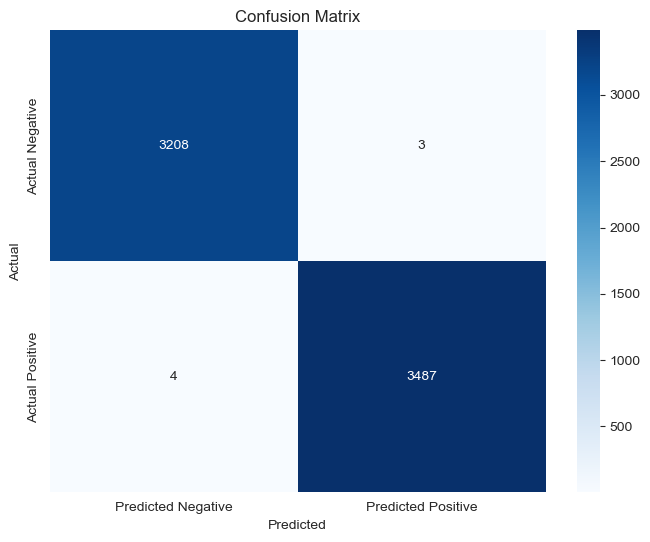

<ipython-input-19-8907d9c53791>:157: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/gdrive/My Drive/best_model.pth'))


The news is: Fake


In [19]:
# Load and split the dataset
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
from torch.utils.data import Subset
from itertools import count
if __name__ == '__main__':
    # scaler = GradScaler('cuda')
    # Load and split the dataset
    fake_file = '/content/gdrive/My Drive/News_dataset/Fake.csv'
    true_file = '/content/gdrive/My Drive/News_dataset/True.csv'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(device)
    tokenizer = Tokenizer(max_length=10240)
    max_length = 512
    batch_size = 4

    dataset = NewsDataset(fake_file, true_file, tokenizer, max_length)

    # subset_size = len(dataset) // 1000
    # indices = torch.randperm(len(dataset))[:subset_size]
    # subset = Subset(dataset, indices)

    train_data, val_data = train_test_split(dataset, test_size=0.2)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size)

    # train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    # val_loader = DataLoader(val_subset, batch_size=batch_size)

    # Hyperparameters to tune
    learning_rates = [0.001]
    dropouts = [0.5, 0.3]
    hidden_dims = [128]
    n_layers_list = [1]
    bidirectional_options = [True]
    embedding_files = ['/content/gdrive/My Drive/glove.6B.100d.txt' ]  # Add paths to your embedding files
    num_epochs = 5
    results = []
    best_val_loss = float('inf')
    best_model = None
    for embedding_file in embedding_files:
        vocab = tokenizer.get_vocab()
        embeddings = load_embeddings(embedding_file, vocab)
        vocab_size = len(tokenizer.get_vocab())
        embedding_dim = embeddings.shape[1]
        pad_idx = tokenizer.pad_token_id
        output_dim = 1
        print("starting")
        for lr in learning_rates:
            for n_layers in n_layers_list:
                if n_layers == 1:
                    dropouts = [0]
                else:
                    dropouts = [0.5, 0.3]
                for dropout in dropouts:
                     for hidden_dim in hidden_dims:
                        for bidirectional in bidirectional_options:
                            # Initialize the model, loss function, and optimizer
                            model = FakeNewsClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout, pad_idx, embeddings).to(device)
                            criterion = nn.BCEWithLogitsLoss()
                            optimizer = optim.Adam(model.parameters(), lr=lr)

                            # Training loop
                            model.train()
                            for epoch in range(num_epochs):
                                epoch_loss = 0
                                running_loss = 0.0
                                running_acc = 0.0

                                for batch_index, batch in enumerate(train_loader):
                                    # input_ids = batch['input_ids'].to(device)
                                    # attention_mask = batch['attention_mask'].to(device)
                                    # labels = batch['label'].unsqueeze(1).float().to(device)
                                    #
                                    # optimizer.zero_grad()
                                    # with autocast('cuda'):
                                    #     outputs = model(input_ids)
                                    #     loss = criterion(outputs, labels)
                                    #
                                    # scaler.scale(loss).backward()
                                    # scaler.step(optimizer)
                                    # scaler.update()
                                    # epoch_loss += loss.item()
                                    input_ids = batch['input_ids'].to(device)
                                    attention_mask = batch['attention_mask'].to(device)
                                    labels = batch['label'].unsqueeze(1).float().to(device)

                                    optimizer.zero_grad()
                                    outputs = model(input_ids)
                                    loss = criterion(outputs, labels)
                                    running_loss += (loss.item() - running_loss) / (batch_index + 1)

                                    loss.backward()
                                    optimizer.step()
                                    acc_t = compute_accuracy(outputs, labels)
                                    running_acc += (acc_t - running_acc) / (batch_index + 1)

                                avg_train_loss = running_loss
                                print(f'Embedding: {embedding_file}, LR: {lr}, Dropout: {dropout}, Hidden Dim: {hidden_dim}, Layers: {n_layers}, Bidirectional: {bidirectional}, Epoch {epoch+1}/{num_epochs}, Loss: {avg_train_loss}, Accuracy: {running_acc}')

                            # Validation loop
                            model.eval()
                            all_labels = []
                            all_preds = []
                            val_loss = 0.
                            val_acc = 0.
                            with torch.no_grad():
                                for batch_index, batch in enumerate(val_loader):
                                    input_ids = batch['input_ids'].to(device)
                                    attention_mask = batch['attention_mask'].to(device)
                                    labels = batch['label'].unsqueeze(1).float().to(device)

                                    outputs = model(input_ids)
                                    loss = criterion(outputs, labels)
                                    val_loss += (loss.item() - val_loss) / (batch_index + 1)
                                    acc_t = compute_accuracy(outputs, labels)
                                    val_acc += (acc_t - val_acc) / (batch_index + 1)
                                            # Collect predictions and true labels
                                    probs = torch.sigmoid(outputs)
                                    preds = (probs > 0.5).float()
                                    all_labels.extend(labels.cpu().numpy())
                                    all_preds.extend(preds.cpu().numpy())


                            results.append((embedding_file, lr, dropout, hidden_dim, n_layers, bidirectional, avg_train_loss, val_loss,val_acc))
                            print(f'Validation Loss: {val_loss}, Validation Accuracy: {val_acc}')
                            conf_matrix = confusion_matrix(all_labels, all_preds)
                            plt.figure(figsize=(8, 6))
                            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
                            plt.xlabel('Predicted')
                            plt.ylabel('Actual')
                            plt.title('Confusion Matrix')
                            plt.show()

                            # Save the best model
                            if val_loss < best_val_loss:
                                best_val_loss = val_loss
                                best_model = model.state_dict()
                                torch.save(best_model, '/content/gdrive/My Drive/best_model.pth')
    vocab = tokenizer.get_vocab()
    embeddings = load_embeddings(embedding_files[0], vocab)
    vocab_size = len(tokenizer.get_vocab())
    embedding_dim = embeddings.shape[1]
    pad_idx = tokenizer.pad_token_id
    output_dim = 1
    model = FakeNewsClassifier(vocab_size, embedding_dim, hidden_dims[0], output_dim, 1, True, 0, pad_idx, embeddings).to(device)

    model.load_state_dict(torch.load('/content/gdrive/My Drive/best_model.pth'))
    model.eval()
    def predict_news(title, text):
        news = title + " " + text
        input_ids, attention_mask = tokenizer.tokenize(news)
        input_ids = input_ids.unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(input_ids)  # Pass attention_mask if required by the model

            prob = torch.sigmoid(output)
            prediction = (prob > 0.5).float().item()

        return "Fake" if prediction == 1 else "Real"

    # sample
    title = "Breaking News: AI Revolutionizes Healthcare"
    text = "In a groundbreaking development, artificial intelligence is now being used to diagnose diseases with unprecedented accuracy. Experts believe this will transform the healthcare industry."

    # predict
    result = predict_news(title, text)
    print(f'The news is: {result}')